In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

class ConditionalVAE(models.Model):
    def __init__(self, img_dim=784, num_classes=10, latent_dim=20, **kwargs):
        super(ConditionalVAE, self).__init__(**kwargs)
        self.img_dim = img_dim
        self.num_classes = num_classes
        self.latent_dim = latent_dim
        
        # 1. ENCODER ARCHITEKTUR
        # Inputs für Bild und Text-Condition
        encoder_img_input = layers.Input(shape=(img_dim,), name="enc_img_input")
        encoder_cond_input = layers.Input(shape=(num_classes,), name="enc_cond_input")
        
        # Verbinden (Concatenation) der Inputs
        x = layers.Concatenate()([encoder_img_input, encoder_cond_input])
        x = layers.Dense(512, activation="relu")(x)
        x = layers.Dense(256, activation="relu")(x)
        
        # Latente Parameter
        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
        
        self.encoder = models.Model([encoder_img_input, encoder_cond_input], [z_mean, z_log_var], name="encoder")
        
        # 2. DECODER ARCHITEKTUR
        # Inputs für latenten Vektor und Text-Condition
        decoder_z_input = layers.Input(shape=(latent_dim,), name="dec_z_input")
        decoder_cond_input = layers.Input(shape=(num_classes,), name="dec_cond_input")
        
        # Verbinden (Concatenation) im Decoder
        x_dec = layers.Concatenate()([decoder_z_input, decoder_cond_input])
        x_dec = layers.Dense(256, activation="relu")(x_dec)
        x_dec = layers.Dense(512, activation="relu")(x_dec)
        decoder_output = layers.Dense(img_dim, activation="sigmoid", name="dec_output")(x_dec)
        
        self.decoder = models.Model([decoder_z_input, decoder_cond_input], decoder_output, name="decoder")
        
        # Metriken für das Tracking beim Training
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def sampling(self, z_mean, z_log_var):
        # Reparameterization Trick
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def train_step(self, data):
        # data besteht aus (Inputs, Targets). Bei VAEs sind die Targets oft egal, 
        # da wir das Bild selbst rekonstruieren. Wir erwarten: (images, conditions)
        images, conditions = data[0]

        with tf.GradientTape() as tape:
            # 1. Enkodieren
            z_mean, z_log_var = self.encoder([images, conditions])
            # 2. Sampeln
            z = self.sampling(z_mean, z_log_var)
            # 3. Dekodieren mit Condition
            reconstruction = self.decoder([z, conditions])
            
            # 4. Losses berechnen
            # Rekonstruktions-Loss (Binary Cross-Entropy zwischen Original und Fälschung)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(images, reconstruction), axis=-1)
            )
            # KL-Divergenz-Loss (Zwingt den latenten Raum zur Standardnormalverteilung)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=-1))
            
            total_loss = reconstruction_loss + kl_loss

        # Gradienten berechnen und Gewichte anpassen
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        # Tracker updaten
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

2026-07-16 17:26:28.048377: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.0) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


In [ ]:
import os
import struct
 
def load_mnist(path, kind='train'):
    """Load MNIST data from `path`"""
    labels_path = os.path.join(path, 
                               '%s-labels-idx1-ubyte' % kind)
    images_path = os.path.join(path, 
                               '%s-images-idx3-ubyte' % kind)
        
    with open(labels_path, 'rb') as lbpath:
        magic, n = struct.unpack('>II', 
                                 lbpath.read(8))
        labels = np.fromfile(lbpath, 
                             dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        magic, num, rows, cols = struct.unpack(">IIII", 
                                               imgpath.read(16))
        images = np.fromfile(imgpath, 
                             dtype=np.uint8).reshape(len(labels), 784)
 
    return images, labels

In [ ]:
import numpy as np

X_train, y_train = load_mnist('/Users/bernd/Dropbox/workspace/VL_CI/python/mnist_data', kind='train')
print('Rows: %d, columns: %d' % (X_train.shape[0], X_train.shape[1]))

X_test, y_test = load_mnist('/Users/bernd/Dropbox/workspace/VL_CI/python/mnist_data', kind='t10k')
print('Rows: %d, columns: %d' % (X_test.shape[0], X_test.shape[1]))

X_train_conv = X_train/255.0
X_test_conv = X_test/255.0

# convert class vectors to binary class matrices
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
# Modell instanziieren und kompilieren
cvae = ConditionalVAE(img_dim=784, num_classes=10, latent_dim=20)
cvae.compile(optimizer=tf.keras.optimizers.Adam())

cvae.encoder.summary()
cvae.decoder.summary()

In [ ]:
# Training starten (X und Y im klassischen Sinne sind hier die Inputs)
cvae.fit([X_train_conv, y_train], epochs=10, batch_size=32)

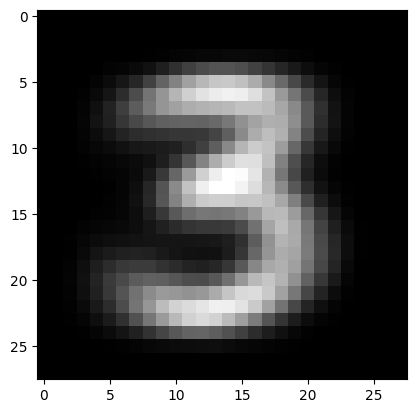

In [26]:
import matplotlib.pyplot as plt

# 1. Erstelle einen zufälligen latenten Punkt im Raum (Stil der Ziffer)
random_latent_vector = tf.random.normal(shape=(1, 20))

# 2. Erstelle die Condition für das Wort "vier" (Index 4 im One-Hot-Vektor)
text_condition = np.array([[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]], dtype="float32")

# 3. Lass den Decoder die "Vier" generieren
generated_img = cvae.decoder([random_latent_vector.numpy(), text_condition])

# 4. Bild wieder in 28x28 Form bringen und anzeigen
generated_img = tf.reshape(generated_img, (28, 28)).numpy()
plt.imshow(generated_img, cmap="gray")
plt.show()